<!-- <img src="../code/Resources/cropped-SummerWorkshop_Header.png">  -->

<h1 align="center">Workshop 1: Tutorial on behavioral states </h1> 
<h3 align="center">Summer Workshop on the Dynamic Brain</h3> 
<h3 align="center">Thursday, August 24th, 2026</h3> 
<h4 align="center">Day 2</h4> 

# intro 

# image

In [39]:
# Standard library
import os  
from pathlib import Path  # Object-oriented filesystem paths

# Data handling packages
import numpy as np  
import numpy.random as npr  
import pandas as pd 
import pynwb  


# Progress bar utility
from tqdm import tqdm  # Displays a smart progress bar during loops

# Preprocessing
from sklearn.preprocessing import StandardScaler  # Standardizes features (zero mean, unit variance)

# Plotting libraries
import matplotlib.pyplot as plt  
from matplotlib import colors  
import seaborn as sns  

# Pandas display settings
pd.set_option('display.max_columns', None)  # Ensures all columns are shown when printing DataFrames

# Inline plotting for Jupyter Notebooks
%matplotlib inline  


##  Load the Dynamic Routing experiment from NWB

In [40]:
example_session_ids =  [
                        '668755_2023-08-31',  '759434_2025-02-04', '713655_2024-08-09', '664851_2023-11-13', '686740_2023-10-24' ,'742903_2024-10-22',\
                        '712815_2024-05-22', '743199_2024-12-05', '686176_2023-12-04', '702131_2024-02-26', '746439_2025-01-31', '667252_2023-09-26',\
                        ]

session_id = example_session_ids[3]
root = Path("/root/capsule/data/dynamicrouting_datacube")

# loop through the directories to find the NWB file for the specific session 
for d in root.iterdir():
    nwb_path = d / f"{session_id}.nwb"
    if nwb_path.exists():
        print(nwb_path)
        break

/root/capsule/data/dynamicrouting_datacube/ecephys_664851_2023-11-13_12-49-51_nwb_2026-07-24_13-29-15/664851_2023-11-13.nwb


In [ ]:
# access the session data with pynwb - should take about a minute
session = pynwb.NWBHDF5IO(nwb_path).read()


# Quick reference of the NWB file structure
# Important groups include: units, trials, intervals, and processing 
session

,timestamps
id,
0,NaN
1,14.56343
2,14.58009
3,14.59676
,timestamps
id,
0,NaN
1,14.99640
2,15.01307


In [42]:
# Get trials dataframe and look at a few rows
trials = session.trials[:]
trials.tail(7)

,start_time,stop_time,quiescent_start_time,quiescent_stop_time,stim_start_time,stim_stop_time,response_window_start_time,response_window_stop_time,task_control_response_time,response_time,reward_time,post_response_window_start_time,post_response_window_stop_time,stim_name,grating_phase,block_index,rewarded_modality,trial_index,trial_index_in_block,repeat_index,is_response,is_correct,is_incorrect,is_hit,is_false_alarm,is_correct_reject,is_miss,is_go,is_nogo,is_rewarded,is_noncontingent_reward,is_contingent_reward,is_reward_scheduled,is_instruction,is_aud_stim,is_vis_stim,is_catch,is_target,is_aud_target,is_vis_target,is_nontarget,is_aud_nontarget,is_vis_nontarget,is_vis_rewarded,is_aud_rewarded,is_block_switch,is_repeat,is_opto,is_task_control_correct
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
517,6712.22169,6717.75970,6712.22169,6713.68959,6713.730710,6714.23071,6713.80640,6714.74054,NaN,NaN,NaN,6714.767940,6717.787150,sound1,NaN,5,vis,517,79.0,0.0,False,True,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,True,True,False,False,False,False,True,False,False,False,False,False
518,6719.99495,6725.53290,6719.99495,6721.46288,6721.523615,6722.04072,6721.57964,6722.51366,6722.04661,6722.04063,6722.06328,6722.541145,6725.560330,vis1,0.5,5,vis,518,80.0,0.0,True,True,False,True,False,False,False,True,False,True,False,True,False,False,False,True,False,True,False,True,False,False,False,True,False,False,False,False,False
519,6725.58292,6731.10424,6725.58292,6727.05079,6727.091960,6727.59196,6727.16756,6728.08506,NaN,NaN,NaN,6728.112460,6731.131690,sound1,NaN,5,vis,519,81.0,0.0,False,True,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,True,True,False,False,False,False,True,False,False,False,False,False
520,6732.07171,6737.60983,6732.07171,6733.55633,6733.617070,6734.11749,6733.67304,6734.59045,NaN,NaN,NaN,6734.617900,6737.637120,vis2,0.5,5,vis,520,82.0,0.0,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,True,True,False,False,False,False,False
521,6739.52790,6745.04926,6739.52790,6740.99584,6741.036860,6741.53686,6741.11254,6742.03005,NaN,NaN,NaN,6742.057500,6745.076682,sound1,NaN,5,vis,521,83.0,0.0,False,True,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,True,True,False,False,False,False,True,False,False,False,False,False
522,6745.59970,6751.10434,6745.59970,6747.06759,6747.108770,6747.60877,6747.18433,6748.10178,NaN,NaN,NaN,6748.129260,6751.131793,sound1,NaN,5,vis,522,84.0,0.0,False,True,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,True,True,False,False,False,False,True,False,False,False,False,False
523,6751.67145,6757.19273,6751.67145,6753.13935,6753.180910,6753.68091,6753.25609,6754.17352,NaN,NaN,NaN,6754.201020,6757.220195,sound2,NaN,5,vis,523,85.0,0.0,False,True,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,True,False,True,False,False,False,False,False


<div style="border-left: 3px solid #000; border-radius: 3px;  padding: 1px; padding-left: 10px; background: #F0FAFF; ">
How well does the mouse modulate its responses to target stimuli based on the context block? We address this by quantifying its response rate for each target stimulus.
</div>

## Mouse behavioral performance over the session

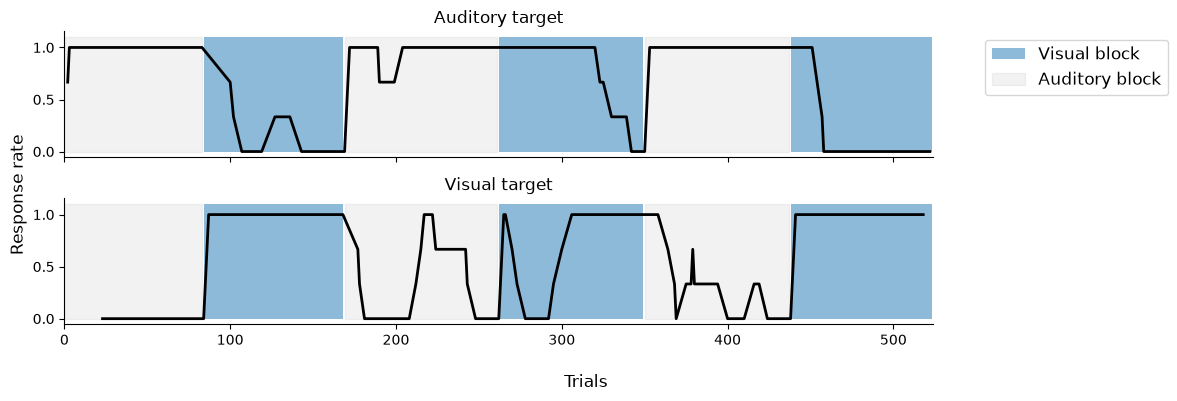

In [43]:
# response rates to target 
vis_target_response_rate =  trials[trials.is_vis_target].is_response.rolling(3).mean()
aud_target_response_rate = trials[trials.is_aud_target].is_response.rolling(3).mean()

fig, axs = plt.subplots(2, 1, figsize = (12, 4), sharex = True, sharey = True)
axs[1].plot(vis_target_response_rate, color = 'k',  lw = 2)
axs[0].plot(aud_target_response_rate, color = 'k', lw = 2)

# add block information 
vis_block = trials.is_vis_rewarded
for ax in axs: 
    ax.fill_between(vis_block.index, 0, 1.1, where=vis_block == 1, alpha=0.5, label = 'Visual block')
    ax.fill_between(vis_block.index, 0, 1.1, where=vis_block == 0, alpha=0.2, label = 'Auditory block', color = 'silver')
    

# formatting
for ax in axs: 
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(0, len(trials))
    ax.set_yticks([0, 0.5, 1])
axs[0].set_title('Auditory target')
axs[1].set_title('Visual target')
axs[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize = 12)

fig.supxlabel('Trials')
fig.supylabel('Response rate')
plt.tight_layout()

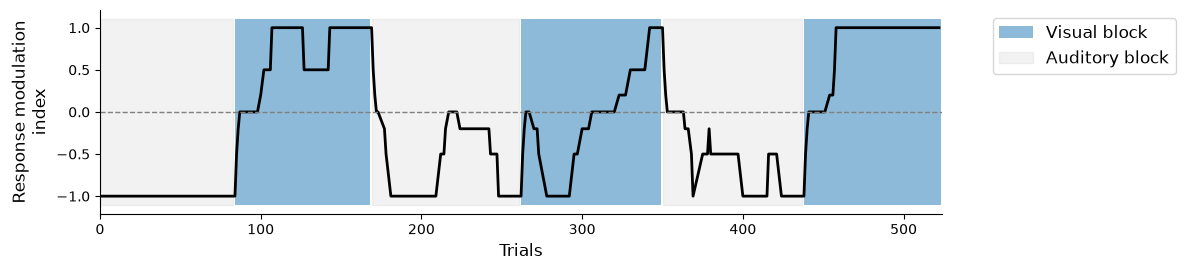

In [44]:
# response modulation index 

# Select target trials and sort by index for consistency
subset_trials = (
    trials.loc[trials.is_vis_target | trials.is_aud_target]
    .sort_index()
    .copy()
)

window = 3  # Define the rolling window size

# Response rate across the most recent visual target trials
vis_target_response_rate = (
    subset_trials[subset_trials.is_vis_target].is_response
    .astype(float)
    .rolling(window=window, min_periods=1)
    .mean()
)

# Response rate across the most recent auditory target trials
aud_target_response_rate = (
    subset_trials[subset_trials.is_aud_target].is_response
    .astype(float)
    .rolling(window=window, min_periods=1)
    .mean()
)

# Place rate estimates back onto the full target-trial sequence, Fill NaN values by propagating
subset_trials["vis_target_response_rate"] = vis_target_response_rate.reindex(subset_trials.index).ffill().fillna(0)
subset_trials["aud_target_response_rate"] = aud_target_response_rate.reindex(subset_trials.index).ffill().fillna(0)


# Response Modualtion index = (vis_target_response_rate - aud_target_response_rate) / (vis_target_response_rate + aud_target_response_rate)
# calculate denominator for response modulation index
denominator = (
    subset_trials["vis_target_response_rate"]
    + subset_trials["aud_target_response_rate"]
)

subset_trials["response_modulation_index"] = np.where(
    denominator > 0,
    (
        subset_trials["vis_target_response_rate"]
        - subset_trials["aud_target_response_rate"]
    ) / denominator,
    np.nan,
)

fig, ax = plt.subplots(figsize = (12, 2.8))
ax.plot(subset_trials["response_modulation_index"], color="k", lw=2)
ax.plot([0, len(trials)], [0, 0], color="gray", lw=1, ls="--")

# add block information 
vis_block = trials.is_vis_rewarded
ax.fill_between(vis_block.index, -1.1, 1.1, where=vis_block == 1, alpha=0.5, label = 'Visual block')
ax.fill_between(vis_block.index, -1.1, 1.1, where=vis_block == 0, alpha=0.2, label = 'Auditory block', color = 'silver')

# formatting
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, len(trials))
ax.set_yticks(np.arange(-1, 1.1, 0.5))
ax.set_xlabel("Trials", fontsize = 12)
ax.set_ylabel("Response modulation\nindex", fontsize = 12)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize = 12)
plt.tight_layout()

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
The mouse modulates its responses according to the current context block, indicating that it transitions between distinct behavioral states. 
</div>

## Identifying behavioral states based on visual inspection

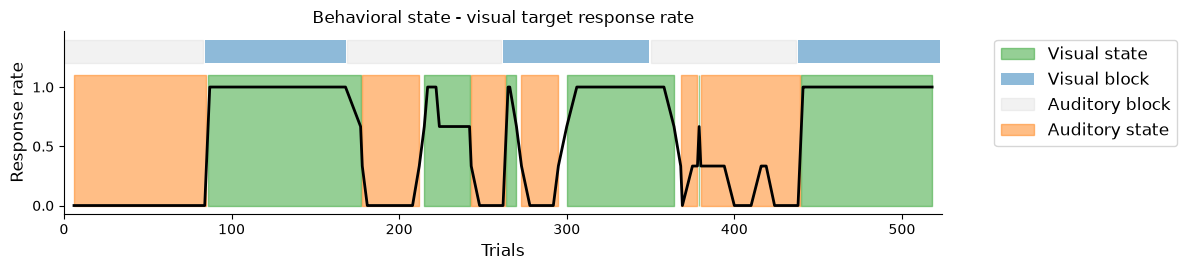

In [45]:
# response rate thresholds for each modality
vis_target_threshold = 0.5
behavioral_state = vis_target_response_rate > vis_target_threshold

fig, ax = plt.subplots(figsize = (12, 2.8))
ax.plot(vis_target_response_rate, color = 'k',  lw = 2)
ax.fill_between(behavioral_state.index, 0, 1.1, where=behavioral_state == 1, alpha=0.5, color = 'tab:green', label = 'Visual state')
ax.fill_between(vis_block.index, 1.2, 1.4, where=vis_block == 1, alpha=0.5, label = 'Visual block')

ax.fill_between(vis_block.index, 1.2, 1.4, where=vis_block == 0, alpha=0.2, label = 'Auditory block', color = 'silver')
ax.fill_between(behavioral_state.index, 0, 1.1, where=behavioral_state == 0, alpha=0.5, color = 'tab:orange', label = 'Auditory state')

# formatting
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("Behavioral state - visual target response rate", fontsize = 12)
ax.set_xlim(0, len(trials))
ax.set_yticks([0, 0.5, 1])
ax.set_xlabel('Trials', fontsize = 12)
ax.set_ylabel('Response rate', fontsize = 12) 
ax.legend(bbox_to_anchor=(1.05, 1), fontsize = 12)
plt.tight_layout()

<div style="background: rgb(32, 177, 13); border-radius: 3px; padding: 10px; color: white;"> 
<p><b>Task 1.1:</b> Using the code above, evaluate behavioral states using auditory target response rates.
</p> </div>

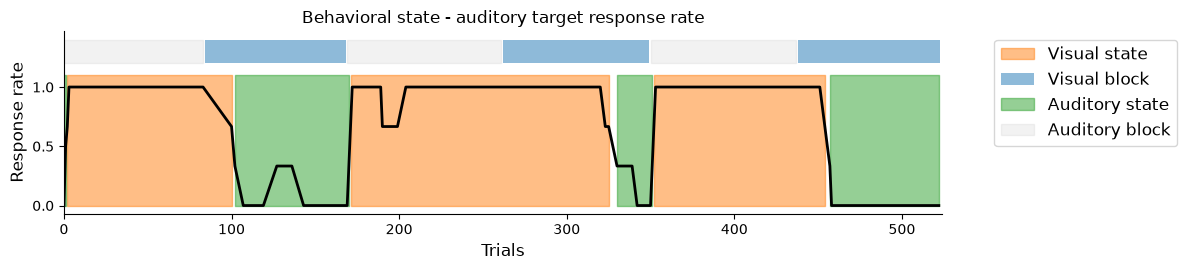

In [46]:
# response rate thresholds for each modality
aud_target_threshold = 0.5
behavioral_state = aud_target_response_rate > aud_target_threshold

fig, ax = plt.subplots(figsize = (12, 2.8))
ax.plot(aud_target_response_rate, color = 'k',  lw = 2)

ax.fill_between(behavioral_state.index, 0, 1.1, where=behavioral_state == 1, alpha=0.5, color = 'tab:orange', label = 'Visual state')
ax.fill_between(vis_block.index, 1.2, 1.4, where=vis_block == 1, alpha=0.5, label = 'Visual block')

ax.fill_between(behavioral_state.index, 0, 1.1, where=behavioral_state == 0, alpha=0.5, color = 'tab:green', label = 'Auditory state')
ax.fill_between(vis_block.index, 1.2, 1.4, where=vis_block == 0, alpha=0.2, label = 'Auditory block', color = 'silver')


# formatting
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("Behavioral state - auditory target response rate", fontsize = 12)
ax.set_xlim(0, len(trials))
ax.set_yticks([0, 0.5, 1])
ax.set_xlabel('Trials', fontsize = 12)
ax.set_ylabel('Response rate', fontsize = 12) 
ax.legend(bbox_to_anchor=(1.05, 1), fontsize = 12)
plt.tight_layout()

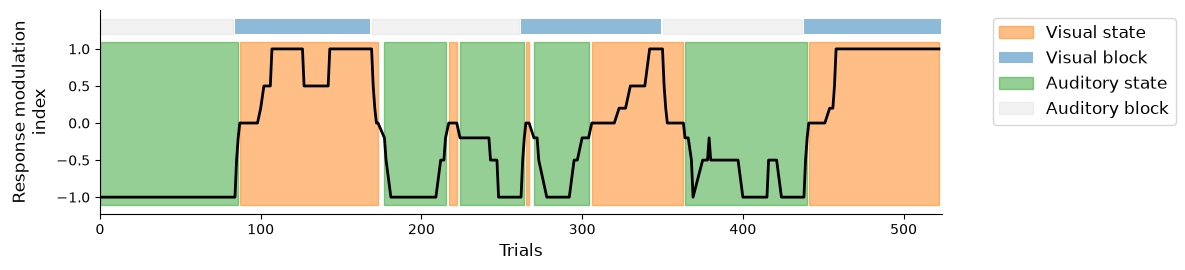

In [47]:
# response rate thresholds for each modality
response_threshold = 0
behavioral_state = subset_trials["response_modulation_index"] >= response_threshold

fig, ax = plt.subplots(figsize = (12, 2.8))
ax.plot( subset_trials["response_modulation_index"], color = 'k',  lw = 2)

ax.fill_between(behavioral_state.index, -1.1, 1.1, where=behavioral_state == 1, alpha=0.5, color = 'tab:orange', label = 'Visual state')
ax.fill_between(vis_block.index, 1.2, 1.4, where=vis_block == 1, alpha=0.5, label = 'Visual block')

ax.fill_between(behavioral_state.index, -1.1, 1.1, where=behavioral_state == 0, alpha=0.5, color = 'tab:green', label = 'Auditory state')
ax.fill_between(vis_block.index, 1.2, 1.4, where=vis_block == 0, alpha=0.2, label = 'Auditory block', color = 'silver')


# formatting
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, len(trials))
ax.set_yticks(np.arange(-1, 1.1, 0.5))
ax.set_xlabel('Trials', fontsize = 12)
ax.set_ylabel('Response modulation\nindex', fontsize = 12) 
ax.legend(bbox_to_anchor=(1.05, 1), fontsize = 12)
plt.tight_layout()

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
When the mouse’s state changes, does it affect other aspects of its behavior too? To answer this, let’s look beyond their task performance and examine additional variables including running speed and pupil position.
</div>

## Do spontaneous behaviors reflect behavioral state?

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
To avoid motor confounds during reward consumption, let’s focus our analysis on the quiescent period.
</div>

In [48]:
def get_trialwise_values(x, timestamps, start, stop):
    """
    Extracts trial-wise summary statistics of different behaviors (mean or median) from a time-aligned signal.

    Parameters:
    - x : array-like
        Signal values (e.g., neural data or behavioral measurements).
    - timestamps : array-like
        Time points corresponding to each value in x.
    - start : array-like
        Start times for each trial.
    - stop : array-like
        Stop times for each trial.

    Returns:
    - values : list
        List of mean or median values for each trial window.
    """
    
    return [np.nanmean(x[np.logical_and(s1 <= timestamps, timestamps <= s2)]) 
            for s1, s2 in zip(start, stop)]

def get_facial_feature(part_name, facial_features_df):
    """
    Extracts and preprocesses the Y-coordinate of a facial feature from a dataframe.

    Parameters:
    ----------
    part_name : str
        The name of the facial feature/part.
    facial_features_df : pandas.DataFrame

    Returns:
    -------
    y : np.ndarray
        Cleaned and interpolated Y-coordinate time series of the feature.
    """

    # Extract likelihood (confidence of detection) for the feature
    confidence = facial_features_df[f'{part_name}_likelihood']

    # Extract temporal norm
    temporal_norm = facial_features_df[f'{part_name}_temporal_norm']

    # Flip Y-coordinate relative to image height
    y = 492 - facial_features_df[f'{part_name}_y']

    # Mask low-confidence or high-temporal-norm points as NaN (to discard unreliable or jumpy detections)
    y[(confidence < 0.99) | 
      (temporal_norm > np.nanmean(temporal_norm) +  2*np.nanstd(temporal_norm))] = np.nan

    # center and remove outliers
    y_centered = y - np.nanmean(y)
    y_abs_centered = np.abs(y_centered)
    y_centered[y_abs_centered > np.nanmean(y_abs_centered) + 2*np.std(y_abs_centered) ]  = np.nan

    # Interpolate missing values (NaNs) to create a continuous time series
    y_interp = pd.Series(y_centered).ffill().bfill().to_numpy()

    return y_interp

In [49]:
# access trials table and get the start and stop times
trial_start = trials.stim_start_time.values - 1.5 
trial_stop = trials.stim_start_time.values 

behavior_data = {}

# facial expressions: 
facial_features_df = session.processing['behavior']['lp_side_camera'][:]
feature_timestamps = facial_features_df['timestamps'].values.astype('float')


ear = get_facial_feature('ear_base_l', facial_features_df)
behavior_data['ear'] = get_trialwise_values(ear, feature_timestamps, trial_start, trial_stop)

nose = get_facial_feature('nose_tip', facial_features_df)
behavior_data['nose'] = get_trialwise_values(nose, feature_timestamps, trial_start, trial_stop)

jaw = get_facial_feature('jaw', facial_features_df)
behavior_data['jaw'] = get_trialwise_values(jaw, feature_timestamps, trial_start, trial_stop)

whisker_pad = get_facial_feature('whisker_pad_l_side', facial_features_df)
behavior_data['whiskers'] = get_trialwise_values(whisker_pad, feature_timestamps, trial_start, trial_stop)

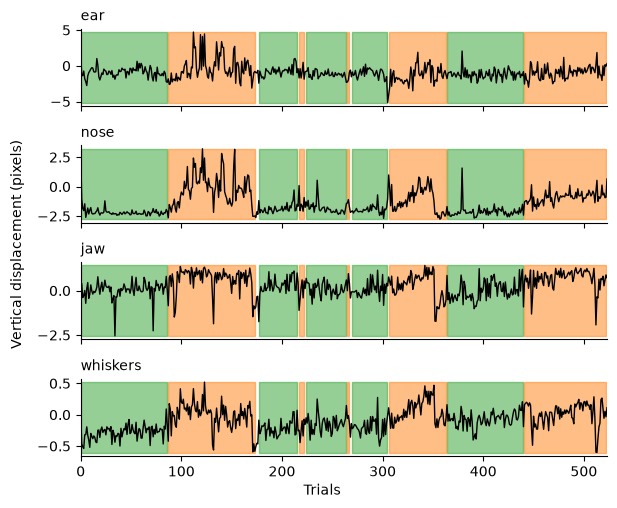

In [50]:
keys_to_plot = ['ear', 'nose', 'jaw', 'whiskers']

fig, ax = plt.subplots(4, 1, figsize = (6, 5), sharex = True)


for i, key in enumerate(keys_to_plot):
    ax[i].plot(trials.index, behavior_data[key], color = 'k', lw = 1)
    ax[i].set_title(key, fontsize = 10, loc = 'left')
    
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)
    ax[i].set_xlim(trials.index[0], trials.index[-1])

    
    # Get min and max of this behavior trace
    min_val = np.nanmin(behavior_data[key])
    max_val = np.nanmax(behavior_data[key])

    # add state information 
    
    ax[i].fill_between(behavioral_state.index,  min_val, max_val, where=behavioral_state == 0, alpha=0.5, color = 'tab:green', label = 'Auditory state')
    ax[i].fill_between(behavioral_state.index,  min_val, max_val, where=behavioral_state == 1, alpha=0.5, color = 'tab:orange', label = 'Visual state')

fig.text(0.5, 0.00, 'Trials', ha='center')
fig.text(-0.02, 0.5, 'Vertical displacement (pixels)', va='center', rotation='vertical')
plt.tight_layout()

<div style="background: rgb(32, 177, 13); border-radius: 3px; padding: 10px; color: white;"> 
<p><b>Task 1.3:</b> Can you make similar plots for pupil size measure and running speed? 
</p> </div>

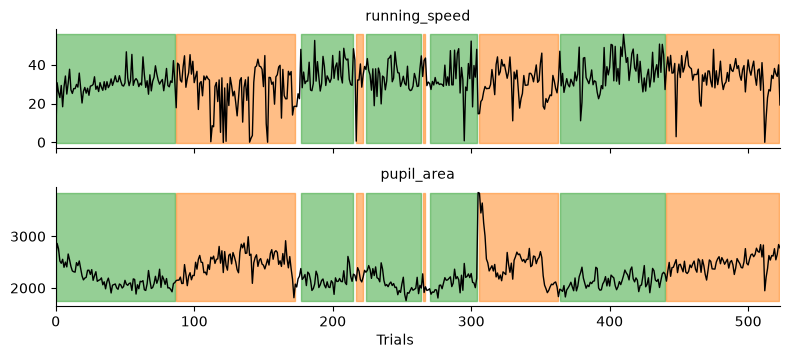

In [51]:
# running speed
running_data = session.processing['behavior']['running_speed']
running_timestamps = running_data.timestamps[:]
running_speed = running_data.data[:]
running_speed = pd.Series(running_speed).interpolate(limit_direction='both').to_numpy() 
behavior_data['running_speed'] = get_trialwise_values(running_speed, running_timestamps, trial_start, trial_stop)


# pupil area
pupil_data = session.processing['behavior']['eye_tracking']
pupil_timestamps = pupil_data.timestamps[:]
pupil_area = pupil_data.pupil_area[:]
pupil_area = pd.Series(pupil_area).interpolate(limit_direction='both').to_numpy() 
behavior_data['pupil_area'] = get_trialwise_values(pupil_area, pupil_timestamps, trial_start, trial_stop)

keys_to_plot = ['running_speed', 'pupil_area']

fig, ax = plt.subplots(2, 1, figsize = (8, 3.5), sharex = True)

for i, key in enumerate(keys_to_plot):
    ax[i].plot(trials.index, behavior_data[key], color = 'k', lw = 1)
    ax[i].set_title(key, fontsize = 10)
    
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)
    ax[i].set_xlim(trials.index[0], trials.index[-1])

    # Get min and max of this behavior trace
    min_val = np.nanmin(behavior_data[key])
    max_val = np.nanmax(behavior_data[key])
    
    # add block information 
    ax[i].fill_between(behavioral_state.index,  min_val, max_val, where=behavioral_state == 0, alpha=0.5, color = 'tab:green', label = 'Auditory state')
    ax[i].fill_between(behavioral_state.index,  min_val, max_val, where=behavioral_state == 1, alpha=0.5, color = 'tab:orange', label = 'Visual state')


fig.text(0.5, 0.00, 'Trials', ha='center')

plt.tight_layout()

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
So, while defining behavioral states by thresholding the hit rate is a useful starting point, it is incomplete. There are several additional variables that could provide more nuanced insights into the mouse’s behavioral states but we have not incorporated these into our definition of behavioral states.

Moreover, the threshold we used to define behavioral states appeared appropriate for the mouse we studied but may not generalize across animals. How, then, can we systematically assess state changes across many mice?

In the remainder of this workshop, we will explore more sophisticated methods for defining behavioral states that integrate multiple features to provide a richer, more reliable description of each mouse’s behavioral profile.

</div>

## Examine covariation between behavioral features

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
First, we'll learn how to make sense of a more complex view of the behavioral information. Instead of looking at just one behavioral variable, we will examine multiple variables simultaneously to gain a better understanding of what's going on. As we have seen, some of these behavior variables correlate with the task-engaged behavioral state and also correlate with each other. Let's create a visualization to see how the different behavioral variables are correlated.

</div>


In [52]:
# Convert behavior_data dictionary to dataframe for ease of use 
behavior_df = pd.DataFrame(behavior_data)
behavior_df.head(7)

,ear,nose,jaw,whiskers,running_speed,pupil_area
0,1.824114,2.860088,0.068056,0.037971,1.692687,2564.948268
1,-1.298965,-1.048895,0.401806,-0.462302,30.726615,2862.673181
2,-1.397897,-1.848811,-0.392006,-0.512761,25.876909,2759.390145
3,-0.737041,-2.030090,-0.281816,-0.538050,23.057643,2521.227279
4,-1.814813,-1.453132,0.006832,-0.320156,29.323374,2478.163154
5,-2.225157,-2.608728,-0.712485,-0.317213,18.322377,2555.334114
6,-2.764556,-2.195714,0.111925,-0.193835,28.603400,2400.525590


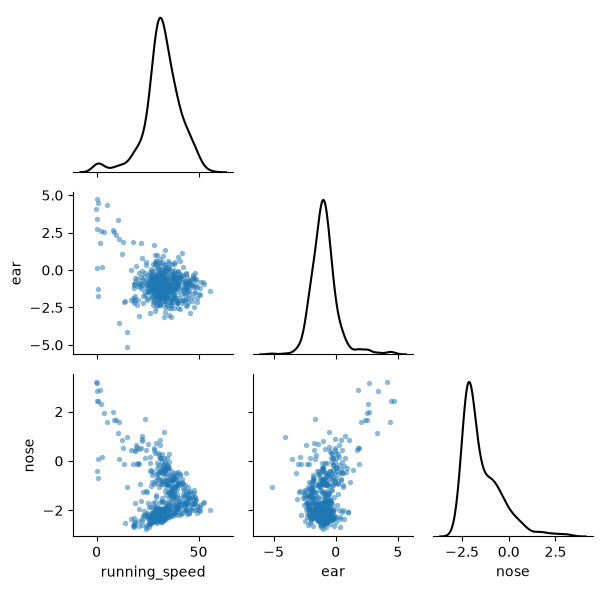

In [53]:
# Variables to include in the pairwise plot
variables = ["running_speed", "ear", "nose"]

# Initialize the PairGrid with only the lower triangle
g = sns.PairGrid(
    behavior_df,
    vars=variables,
    corner=True,
    diag_sharey=False,
)

# Plot scatterplots in the lower triangle
g.map_lower(
    sns.scatterplot,
    s=15,
    alpha=0.5,
    linewidth=0,
)

# Plot 1D kernel density estimates along the diagonal
g.map_diag(
    sns.kdeplot,
    bw_method="scott",
    legend=False,
    color = 'k'
)

# Formatting
g.figure.set_size_inches(6, 6)
g.figure.tight_layout()
plt.show()

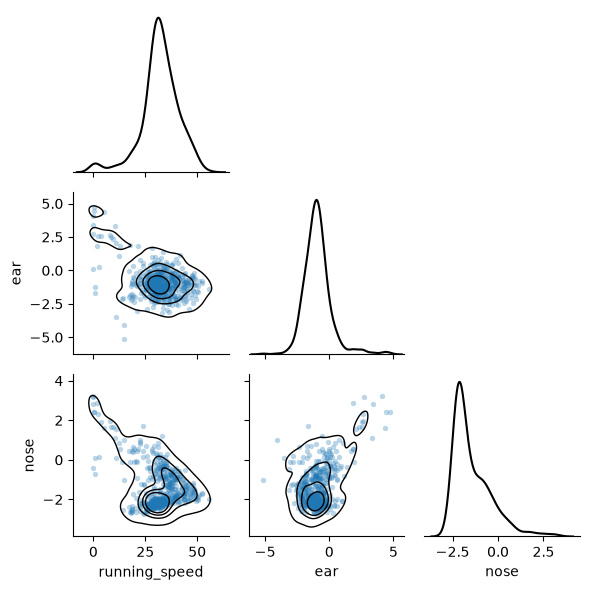

In [54]:
# Variables to include in the pairwise plot
variables = ["running_speed", "ear", "nose"]

# Bandwidth method for KDE
width = "scott"

# Initialize the PairGrid with only the lower triangle
g = sns.PairGrid(
    behavior_df,
    vars=variables,
    corner=True,
    diag_sharey=False,
)

# Plot scatterplots in the lower triangle
g.map_lower(
    sns.scatterplot,
    s=15,
    alpha=0.3,
    linewidth=0,
)

# Overlay 2D kernel density contours
g.map_lower(
    sns.kdeplot,
    bw_method=width,
    levels=5,      # Number of contour levels
    color="k",     # Black contour lines
    linewidths=1,
)

# Plot 1D kernel density estimates along the diagonal
g.map_diag(
    sns.kdeplot,
    bw_method=width,
    legend=False,
    color = 'k'
)

# Formatting
g.figure.set_size_inches(6, 6)
g.figure.tight_layout()

plt.show()

<div style="background: rgb(32, 177, 13); border-radius: 3px; padding: 10px; color: white;"> 
Task 2.3: In the pairwise density plots, try playing around with the option 'bw_method' by setting it to scalar values between [0.2, 1]. How does this affect the density plots? Do you still think there are only 2 states? Do this below. 
</div>

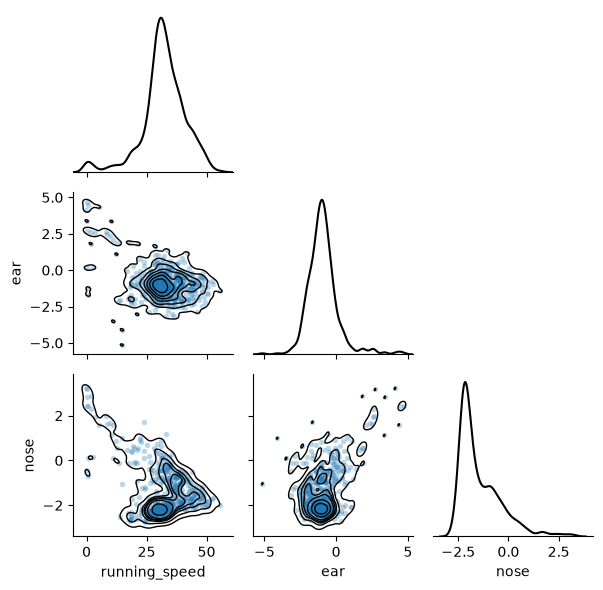

In [55]:
# Variables to include in the pairwise plot
variables = ["running_speed", "ear", "nose"]

# Bandwidth method for KDE
width = 0.2

# Initialize the PairGrid with only the lower triangle
g = sns.PairGrid(
    behavior_df,
    vars=variables,
    corner=True,
    diag_sharey=False,
)

# Plot scatterplots in the lower triangle
g.map_lower(
    sns.scatterplot,
    s=15,
    alpha=0.3,
    linewidth=0,
)

# Overlay 2D kernel density contours
g.map_lower(
    sns.kdeplot,
    bw_method=width,
    levels=8,      # Number of contour levels
    color="k",     # Black contour lines
    linewidths=1,
)

# Plot 1D kernel density estimates along the diagonal
g.map_diag(
    sns.kdeplot,
    bw_method=width,
    legend=False,
    color = 'k'
)

# Formatting
g.figure.set_size_inches(6, 6)
g.figure.tight_layout()

plt.show()

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
This visualization broadly showed two states that mapped well to our previous state definitions. But playing around with the density plots may have raised some doubts that there were only two states.

Does every peak deserve a behavior state? How can we define state boundaries while incorporating all behavior variables? Are there other behavior states?

Moreover, when determining behavioral states, we are dealing with data that changes over time, where the current state may depend on the current observation and also on the previous state. How do we incorporate time information?!
</div>

## !! Whiteboard session !! 